# Masterclass final: Deep Learning vs modelos tradicionales en visión
## MNIST Ultra Pro Full
### Autor: Josef Rodriguez



# Objetivo de la clase

En esta clase construiremos una comparación seria entre modelos tradicionales de Machine Learning y modelos de Deep Learning usando el dataset **MNIST**.

La meta no es solamente entrenar una red neuronal. La meta es responder, con evidencia experimental y criterio técnico, las siguientes preguntas:

$$
\text{¿Cuándo Deep Learning supera a modelos tradicionales?}
$$

$$
\text{¿Por qué una CNN tiene ventaja sobre modelos clásicos en imágenes?}
$$

$$
\text{¿Qué lecciones de producción podemos extraer de este experimento?}
$$

Trabajaremos con cuatro enfoques:

1. Logistic Regression
2. Random Forest
3. MLP
4. CNN

Además, incluiremos:

- formulación matemática
- análisis visual
- curvas de entrenamiento
- matriz de confusión
- análisis de errores
- visualización de filtros
- mapas de activación
- saliency maps
- conclusiones industriales



# Agenda de la clase

## Bloque 1. Fundamento conceptual
- Qué es MNIST
- Cómo se formula el problema
- Por qué este dataset es ideal para comparar ML vs DL

## Bloque 2. Modelos tradicionales
- Logistic Regression
- Random Forest

## Bloque 3. Deep Learning
- MLP
- CNN

## Bloque 4. Evaluación comparativa
- accuracy
- matriz de confusión
- errores
- ejemplos visuales

## Bloque 5. Interpretabilidad y entendimiento
- filtros
- activaciones
- saliency

## Bloque 6. Cierre industrial
- cuándo usar DL
- cuándo no usar DL
- mensajes finales para producción


# 1. ¿Qué es MNIST?

MNIST es uno de los datasets clásicos de visión por computadora.

Contiene imágenes en escala de grises de dígitos escritos a mano. Cada observación corresponde a una clase entre 10 posibles categorías:

$$
y \in \{0,1,2,3,4,5,6,7,8,9\}
$$

Cada imagen tiene tamaño:

$$
28 \times 28
$$

Por tanto, cada observación contiene:

$$
28 \times 28 = 784 \text{ pixeles}
$$

MNIST es útil para esta clase porque:

- es suficientemente simple para enseñar
- permite comparar modelos rápidamente
- muestra con claridad por qué las arquitecturas convolucionales tienen ventaja en visión

---

# 2. Formulación matemática del problema

Queremos aprender una función:

$$
f(X) = \hat{y}
$$

donde:

- $X$ es la imagen de entrada
- $\hat{y}$ es la clase predicha

Más precisamente, el modelo produce una distribución de probabilidad:

$$
\hat{\mathbf{p}} = (\hat{p}_0, \hat{p}_1, \dots, \hat{p}_9)
$$

cumpliendo:

$$
\sum_{k=0}^{9} \hat{p}_k = 1
$$

La clase estimada es:

$$
\hat{y} = \arg\max_k \hat{p}_k
$$

---

# 3. Función de pérdida

Para clasificación multiclase usamos la entropía cruzada:

$$
\mathcal{L} = - \sum_{i=1}^{N} \sum_{k=0}^{9} y_{ik}\log(\hat{p}_{ik})
$$

donde:

- $y_{ik}=1$ si la observación $i$ pertenece a la clase $k$
- $y_{ik}=0$ en otro caso
- $\hat{p}_{ik}$ es la probabilidad predicha para la clase $k$

Esta pérdida penaliza con fuerza las predicciones incorrectas cuando el modelo está muy confiado.

---

# 4. Hipótesis de la clase

Esperamos observar algo como lo siguiente:

| Modelo | Tipo | Performance esperada |
|---|---|---|
| Logistic Regression | Modelo lineal | buena, pero limitada |
| Random Forest | Modelo no lineal clásico | mejor que lineal |
| MLP | Red neuronal densa | fuerte |
| CNN | Red neuronal convolucional | la mejor |

La razón esperada es estructural:

- los modelos clásicos trabajan con la imagen aplanada
- la MLP aprende no linealidad, pero sigue ignorando la geometría local
- la CNN explota explícitamente la estructura espacial de la imagen


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)


# 5. Carga de datos

Usaremos `mnist.load_data()`. La primera vez puede descargar el dataset y luego queda almacenado localmente en caché.

Esto es suficiente para docencia y experimentación, pero en producción un dataset no debería depender de una descarga dinámica. Lo correcto sería trabajar con versionado formal del dato.


In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


X_train: (60000, 28, 28)
y_train: (60000,)
X_test : (10000, 28, 28)
y_test : (10000,)


# 6. Exploración visual inicial

Antes de modelar, es importante entender el dato.

En imágenes, una parte esencial de la exploración consiste en ver ejemplos reales. Esto ayuda a:

- validar que el dataset se cargó correctamente
- observar variabilidad
- identificar dificultad intrínseca
- construir intuición sobre posibles errores del modelo


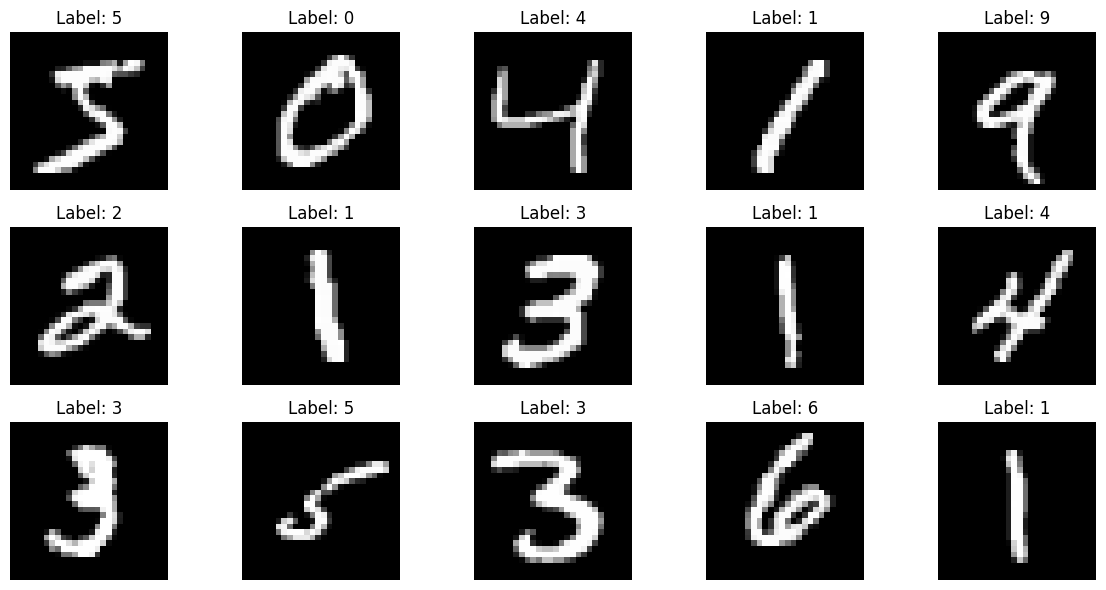

In [3]:
plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [4]:
unique, counts = np.unique(y_train, return_counts=True)
dist_train = pd.DataFrame({"digit": unique, "count": counts})
dist_train


,digit,count
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


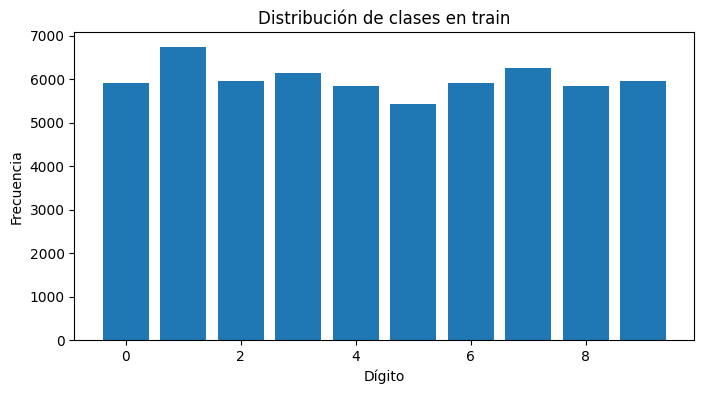

In [5]:
plt.figure(figsize=(8, 4))
plt.bar(dist_train["digit"], dist_train["count"])
plt.title("Distribución de clases en train")
plt.xlabel("Dígito")
plt.ylabel("Frecuencia")
plt.show()


# 7. Preprocesamiento

## 7.1 Normalización

Los pixeles toman valores entre 0 y 255. Normalizamos para llevarlos a:

$$
X_{\text{norm}} = \frac{X}{255}
$$

Esto mejora la estabilidad numérica del entrenamiento.

## 7.2 Flatten para modelos tradicionales y MLP

Los modelos tradicionales no operan naturalmente sobre matrices 2D de imágenes. Por ello transformamos:

$$
X \in \mathbb{R}^{28 \times 28}
\rightarrow
x \in \mathbb{R}^{784}
$$

Al hacer esto, el modelo pierde la estructura espacial local.

## 7.3 Tensor 4D para CNN

La CNN usará la representación:

$$
X \in \mathbb{R}^{28 \times 28 \times 1}
$$

donde el último eje representa el canal de la imagen.


In [6]:
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

X_train_flat = X_train_norm.reshape(-1, 28 * 28)
X_test_flat = X_test_norm.reshape(-1, 28 * 28)

X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

print("X_train_flat:", X_train_flat.shape)
print("X_test_flat :", X_test_flat.shape)
print("X_train_cnn :", X_train_cnn.shape)
print("X_test_cnn  :", X_test_cnn.shape)


X_train_flat: (60000, 784)
X_test_flat : (10000, 784)
X_train_cnn : (60000, 28, 28, 1)
X_test_cnn  : (10000, 28, 28, 1)


# 8. Modelo 1: Logistic Regression

La regresión logística multiclase usa la función softmax:

$$
P(y=k \mid x) = \frac{e^{z_k}}{\sum_{j=0}^{9} e^{z_j}}
$$

donde:

$$
z_k = w_k^\top x + b_k
$$

Este modelo es lineal respecto a la entrada.

## Interpretación conceptual

Ventajas:

- simple
- rápido
- baseline fuerte
- muy útil como punto de comparación

Limitaciones:

- trata cada pixel como una variable en un vector
- no modela explícitamente estructura espacial
- no aprende patrones jerárquicos visuales


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(
    max_iter=300,
    solver="saga",
    n_jobs=-1,
    verbose=1
)

lr.fit(X_train_flat, y_train)

pred_lr = lr.predict(X_test_flat)
acc_lr = accuracy_score(y_test, pred_lr)

print("Accuracy Logistic Regression:", round(acc_lr, 4))


/Users/josefrodriguez/repos/ML_course/ML-course/ml_course_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Epoch 1, change: 1
Epoch 2, change: 0.25167224
Epoch 3, change: 0.13403128
Epoch 4, change: 0.10478862
Epoch 5, change: 0.071480781
Epoch 6, change: 0.05671012
Epoch 7, change: 0.04795929
Epoch 8, change: 0.041670073
Epoch 9, change: 0.036003206
Epoch 10, change: 0.033629011
Epoch 11, change: 0.030566895
Epoch 12, change: 0.027499191
Epoch 13, change: 0.026719751
Epoch 14, change: 0.024625149
Epoch 15, change: 0.021618795
Epoch 16, change: 0.021351434
Epoch 17, change: 0.020717081
Epoch 18, change: 0.02053839
Epoch 19, change: 0.020172739
Epoch 20, change: 0.017550567
Epoch 21, change: 0.016076447
Epoch 22, change: 0.01583875
Epoch 23, change: 0.015761049
Epoch 24, change: 0.015441182
Epoch 25, change: 0.015096091
Epoch 26, change: 0.01509712
Epoch 27, change: 0.01474239
Epoch 28, change: 0.014682116
Epoch 29, change: 0.01454646
Epoch 30, change: 0.011017901
Epoch 31, change: 0.010924513
Epoch 32, change: 0.01069911
Epoch 33, change: 0.010659947
Epoch 34, change: 0.010523235
Epoch 35, 

/Users/josefrodriguez/repos/ML_course/ML-course/ml_course_env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# 9. Modelo 2: Random Forest

Random Forest combina múltiples árboles de decisión:

$$
\hat{f}(x) = \frac{1}{B}\sum_{b=1}^{B} T_b(x)
$$

donde:

- $T_b(x)$ es la predicción del árbol $b$
- $B$ es el número total de árboles

## Interpretación conceptual

Ventajas:

- captura no linealidad
- captura interacciones
- suele mejorar claramente a modelos lineales

Limitación importante en visión:

aunque aprende relaciones más complejas, sigue trabajando sobre la imagen aplanada. Es decir, no incorpora la noción de vecindad local ni el sesgo inductivo espacial de una CNN.


In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_flat, y_train)
pred_rf = rf.predict(X_test_flat)
acc_rf = accuracy_score(y_test, pred_rf)

print("Accuracy Random Forest:", round(acc_rf, 4))


Accuracy Random Forest: 0.9692


# 10. Modelo 3: MLP

Una red neuronal densa modela transformaciones sucesivas:

$$
h^{(1)} = \phi(W^{(1)}x + b^{(1)})
$$

$$
h^{(2)} = \phi(W^{(2)}h^{(1)} + b^{(2)})
$$

$$
\hat{y} = \text{softmax}(W^{(L)}h^{(L-1)} + b^{(L)})
$$

donde $\phi$ suele ser una activación no lineal como ReLU.

## ¿Qué mejora respecto a modelos clásicos?

- aprende no linealidades complejas
- tiene mayor capacidad de representación
- puede aproximar funciones más ricas

## ¿Qué limitación mantiene?

Aunque es Deep Learning, la MLP sigue viendo la imagen como un vector de 784 entradas. No sabe que pixeles cercanos en la imagen están relacionados espacialmente.


In [9]:
mlp = Sequential([
    Input(shape=(784,)),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])

mlp.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_mlp = mlp.fit(
    X_train_flat, y_train,
    validation_split=0.2,
    epochs=12,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8899 - loss: 0.3702 - val_accuracy: 0.9581 - val_loss: 0.1432
Epoch 2/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9521 - loss: 0.1594 - val_accuracy: 0.9673 - val_loss: 0.1089
Epoch 3/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9659 - loss: 0.1146 - val_accuracy: 0.9721 - val_loss: 0.0939
Epoch 4/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9726 - loss: 0.0915 - val_accuracy: 0.9734 - val_loss: 0.0894
Epoch 5/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9773 - loss: 0.0733 - val_accuracy: 0.9753 - val_loss: 0.0817
Epoch 6/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9804 - loss: 0.0612 - val_accuracy: 0.9765 - val_loss: 0.0825
Epoch 7/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9825 - loss: 0.0529 - val_accuracy: 0.9777 - val_loss: 0.0794
Epoch 8/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9847 - loss: 0.0476 - val_accuracy: 0.

In [10]:
loss_mlp, acc_mlp = mlp.evaluate(X_test_flat, y_test, verbose=0)
pred_mlp_prob = mlp.predict(X_test_flat, verbose=0)
pred_mlp = np.argmax(pred_mlp_prob, axis=1)

print("Accuracy MLP:", round(acc_mlp, 4))


Accuracy MLP: 0.9808


# 11. Modelo 4: CNN

La CNN es la arquitectura clave de esta clase.

## 11.1 Convolución

Una convolución aplica filtros locales sobre la imagen:

$$
S(i,j) = (X * K)(i,j) = \sum_m \sum_n X(i-m, j-n)K(m,n)
$$

Esto permite detectar patrones locales como:

- bordes
- esquinas
- curvas
- trazos

## 11.2 Pooling

Luego usamos max pooling:

$$
h_{\text{pool}} = \max(h_{\text{window}})
$$

Esto ayuda a:

- reducir dimensionalidad
- concentrar información relevante
- hacer más robusta la representación

## 11.3 Idea jerárquica

Las primeras capas aprenden trazos simples.

Las capas intermedias aprenden combinaciones de trazos.

Las capas más profundas aprenden patrones globales asociados a clases completas.

Por eso una CNN no solo aprende "más". Aprende de una manera estructuralmente más adecuada para imágenes.


In [11]:
cnn = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

cnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9128 - loss: 0.2861 - val_accuracy: 0.9776 - val_loss: 0.0757
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9739 - loss: 0.0830 - val_accuracy: 0.9859 - val_loss: 0.0514
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9814 - loss: 0.0592 - val_accuracy: 0.9876 - val_loss: 0.0436
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9851 - loss: 0.0469 - val_accuracy: 0.9879 - val_loss: 0.0403
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9879 - loss: 0.0391 - val_accuracy: 0.9881 - val_loss: 0.0415
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9903 - loss: 0.0317 - val_accuracy: 0.9883 - val_loss: 0.0408


In [12]:
loss_cnn, acc_cnn = cnn.evaluate(X_test_cnn, y_test, verbose=0)
pred_cnn_prob = cnn.predict(X_test_cnn, verbose=0)
pred_cnn = np.argmax(pred_cnn_prob, axis=1)

print("Accuracy CNN:", round(acc_cnn, 4))


Accuracy CNN: 0.9898


# 12. Comparación global de resultados

Hasta aquí ya podemos comparar modelos.

La idea central de la clase no es solamente mirar cuál gana, sino conectar el resultado con la estructura del dato y con la arquitectura elegida.


In [13]:
results = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest", "MLP", "CNN"],
    "Accuracy": [acc_lr, acc_rf, acc_mlp, acc_cnn]
}).sort_values("Accuracy", ascending=False)

results


,Modelo,Accuracy
3,CNN,0.9898
2,MLP,0.9808
1,Random Forest,0.9692
0,Logistic Regression,0.9258


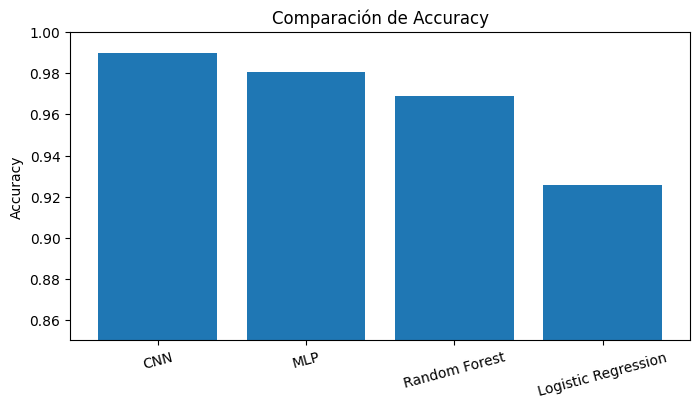

In [14]:
plt.figure(figsize=(8, 4))
plt.bar(results["Modelo"], results["Accuracy"])
plt.ylim(0.85, 1.0)
plt.title("Comparación de Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()


# 13. Curvas de entrenamiento

Las curvas de entrenamiento permiten responder preguntas importantes:

- ¿el modelo está aprendiendo?
- ¿hay sobreajuste?
- ¿hay subajuste?
- ¿la validación acompaña al entrenamiento?

Esta lectura es clave en Deep Learning y en producción.


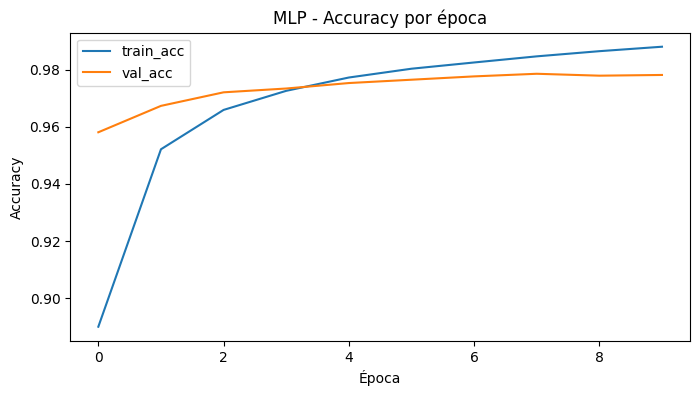

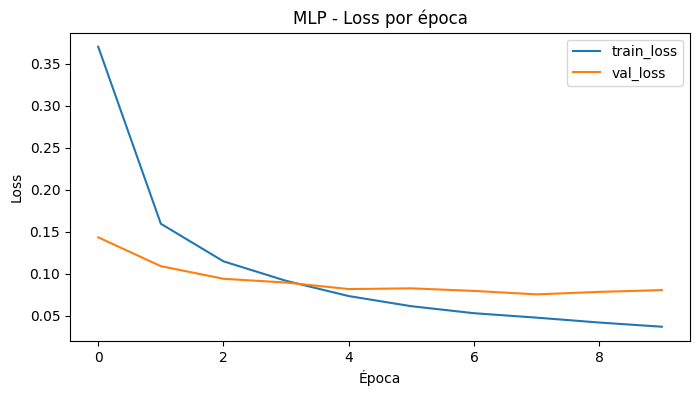

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(history_mlp.history["accuracy"], label="train_acc")
plt.plot(history_mlp.history["val_accuracy"], label="val_acc")
plt.title("MLP - Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_mlp.history["loss"], label="train_loss")
plt.plot(history_mlp.history["val_loss"], label="val_loss")
plt.title("MLP - Loss por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()


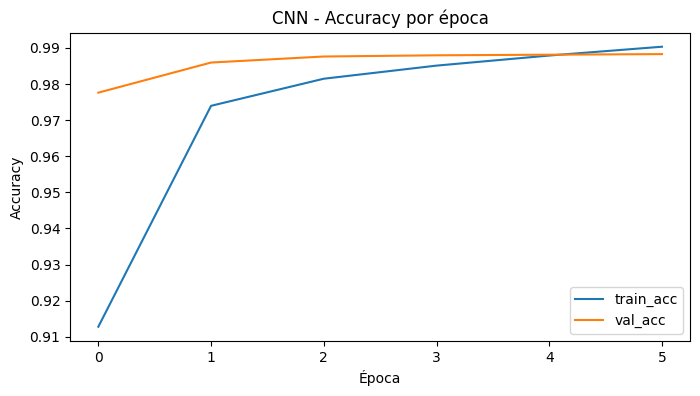

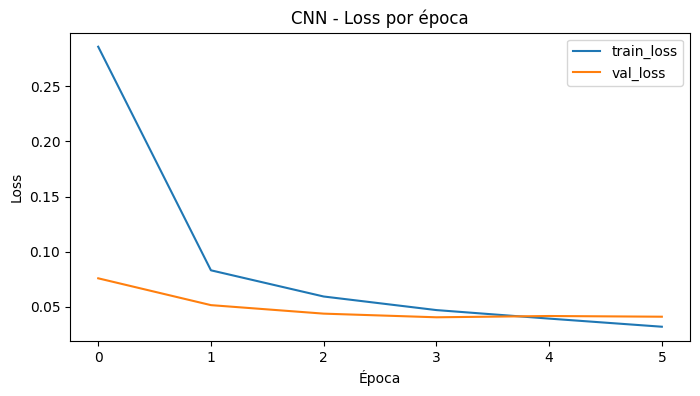

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history["accuracy"], label="train_acc")
plt.plot(history_cnn.history["val_accuracy"], label="val_acc")
plt.title("CNN - Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history["loss"], label="train_loss")
plt.plot(history_cnn.history["val_loss"], label="val_loss")
plt.title("CNN - Loss por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()


# 14. Matrices de confusión

Una buena accuracy global no siempre cuenta toda la historia. La matriz de confusión permite ver:

- qué clases se confunden
- dónde comete errores cada modelo
- si ciertas clases son consistentemente difíciles


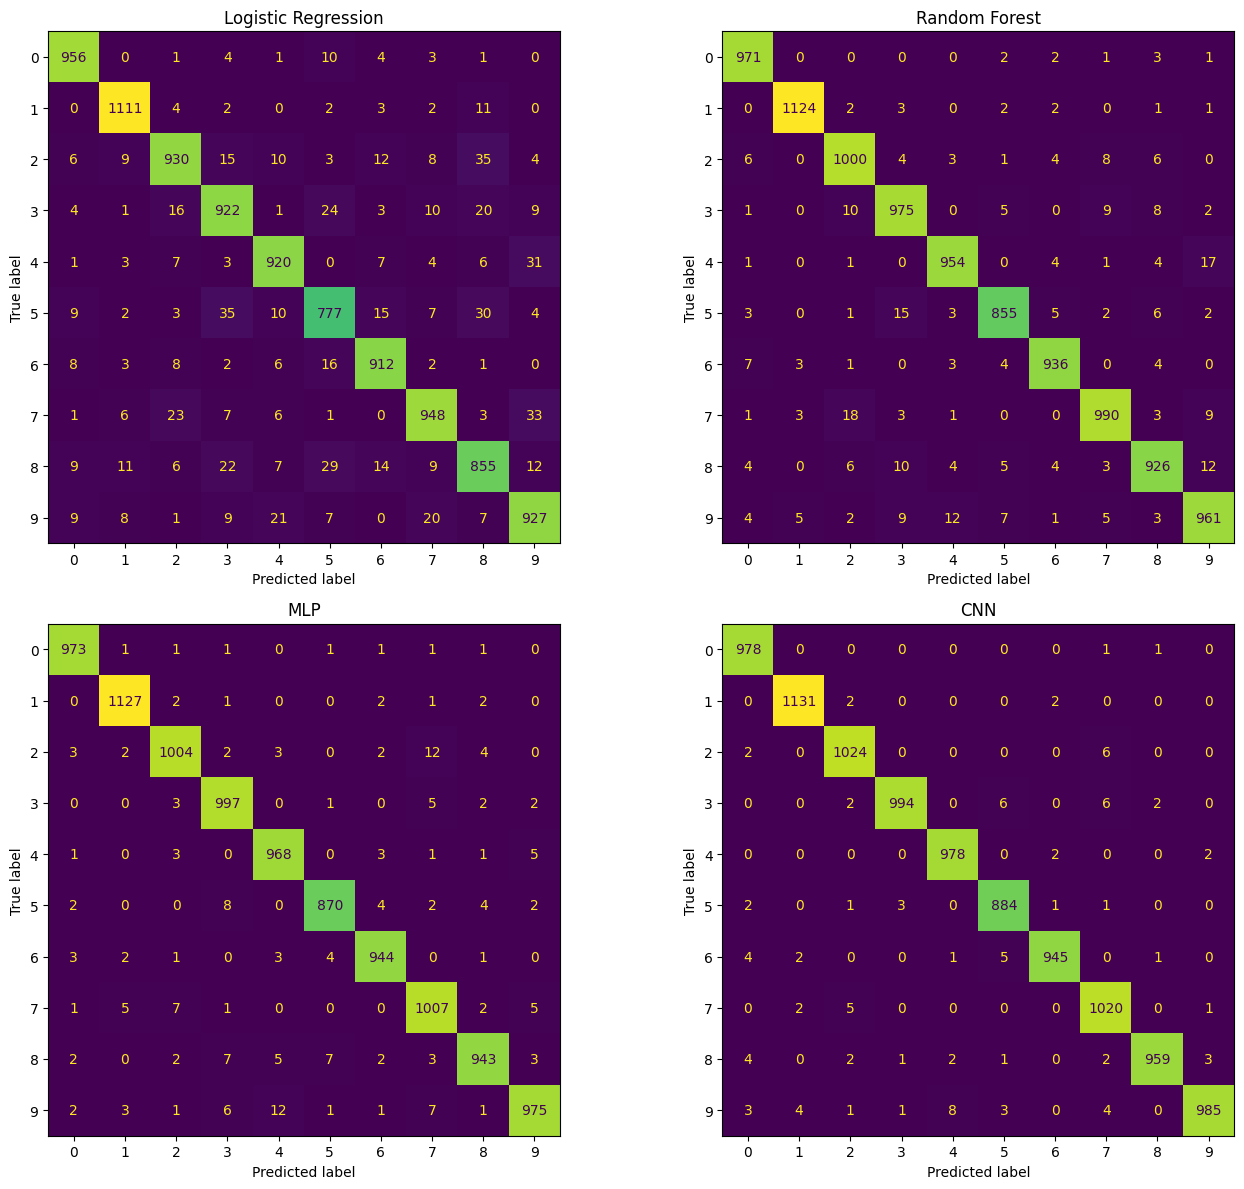

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

models_preds = [
    ("Logistic Regression", pred_lr),
    ("Random Forest", pred_rf),
    ("MLP", pred_mlp),
    ("CNN", pred_cnn)
]

for ax, (name, preds) in zip(axes.ravel(), models_preds):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


# 15. Reporte detallado del mejor modelo

El reporte de clasificación del mejor modelo nos permite revisar precisión, recall y F1-score por clase. En problemas reales, esta desagregación es indispensable.


In [18]:
print(classification_report(y_test, pred_cnn))


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.98      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



# 16. Predicciones visuales

Ahora veremos ejemplos concretos de predicciones de la CNN. Esto es muy útil para docencia porque conecta el score numérico con ejemplos reales.


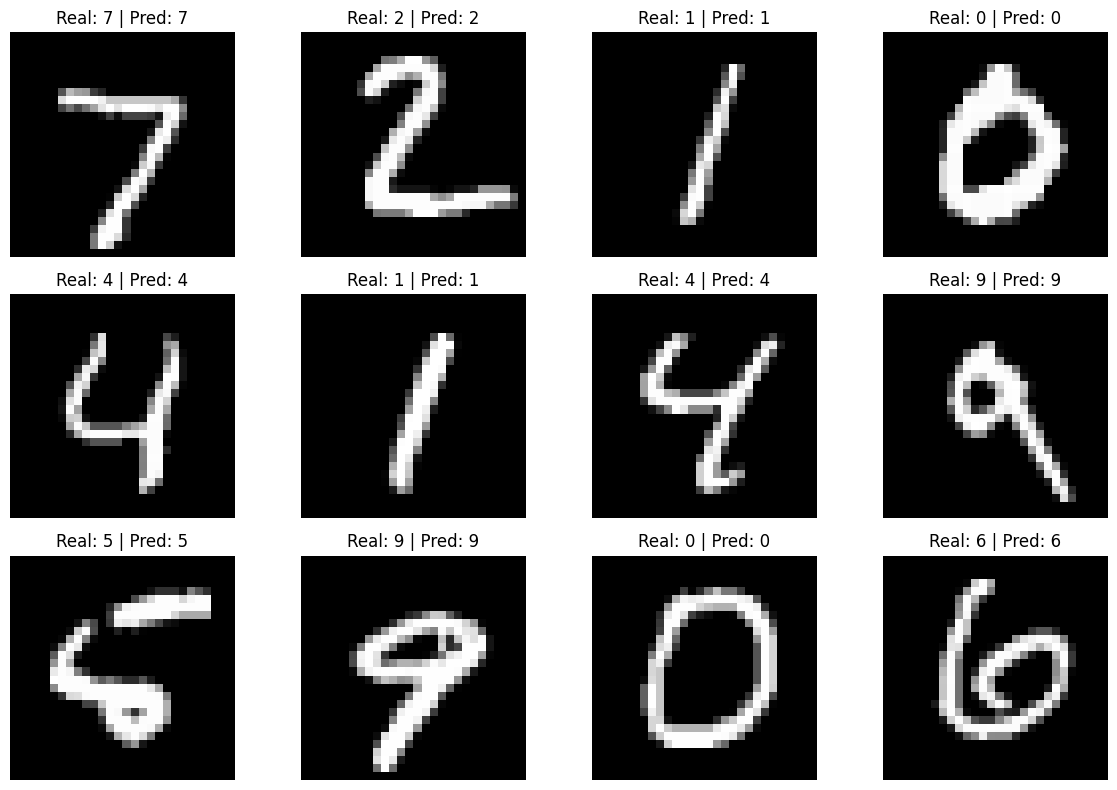

In [19]:
plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Real: {y_test[i]} | Pred: {pred_cnn[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


# 17. Análisis de errores

En Deep Learning no basta con reportar accuracy. También debemos entender:

- cuántos errores hay
- qué tipo de errores hay
- si los errores son ambiguos incluso para un humano
- si existen patrones sistemáticos

Esto conecta directamente con la forma seria de evaluar modelos en producción.


In [20]:
errors = np.where(pred_cnn != y_test)[0]
print("Número de errores CNN:", len(errors))


Número de errores CNN: 102


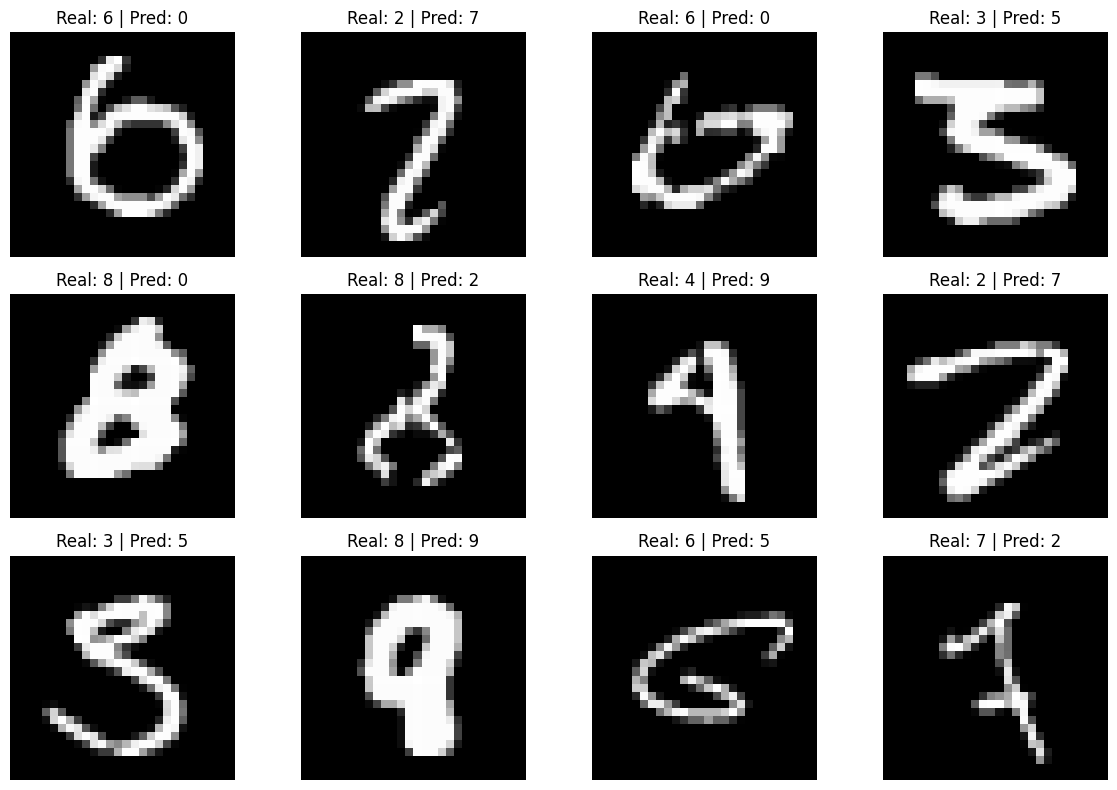

In [21]:
plt.figure(figsize=(12, 8))
for i, idx in enumerate(errors[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"Real: {y_test[idx]} | Pred: {pred_cnn[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


# 18. Predicciones correctas con alta confianza

No solo interesa el error. También interesa ver cuándo el modelo está muy seguro y además acierta.


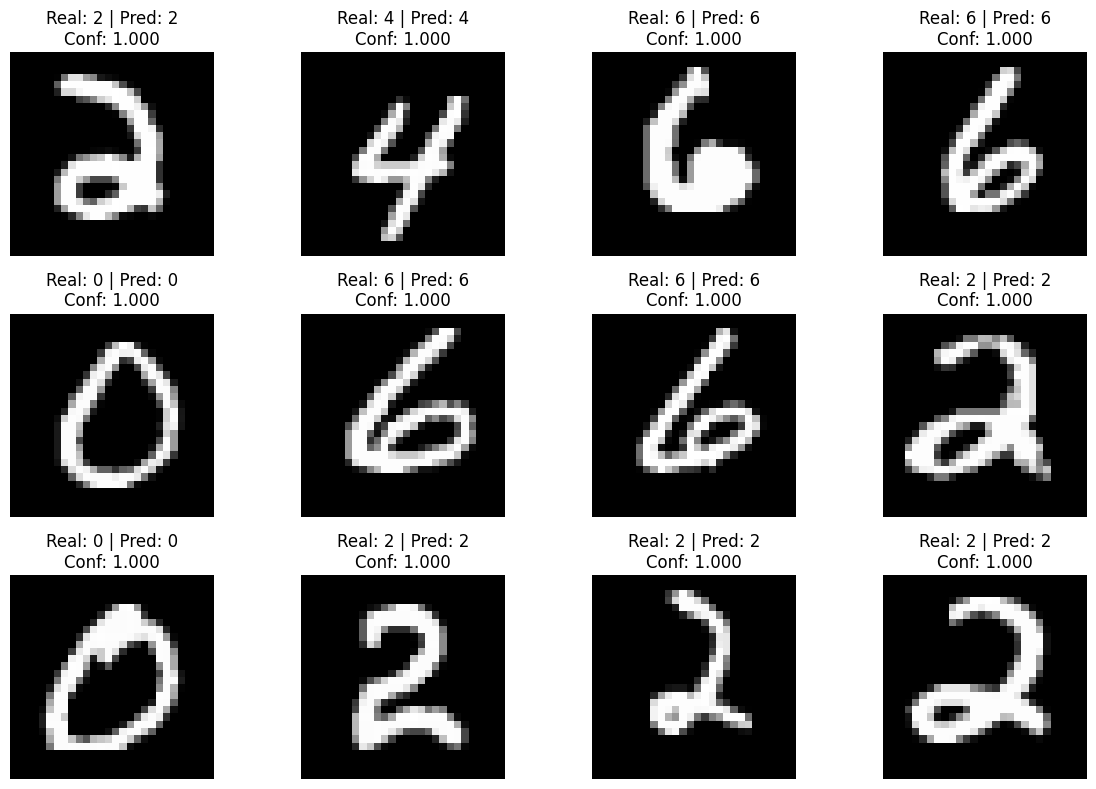

In [22]:
confidence = pred_cnn_prob.max(axis=1)
correct_idx = np.where(pred_cnn == y_test)[0]
top_correct = correct_idx[np.argsort(confidence[correct_idx])[-12:]]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(top_correct):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"Real: {y_test[idx]} | Pred: {pred_cnn[idx]}\nConf: {confidence[idx]:.3f}")
    plt.axis("off")
plt.tight_layout()
plt.show()


# 19. Predicciones erróneas con alta confianza

Estos casos son especialmente valiosos porque muestran situaciones donde el modelo está muy convencido pero se equivoca. En producción, estos suelen ser los casos más delicados.


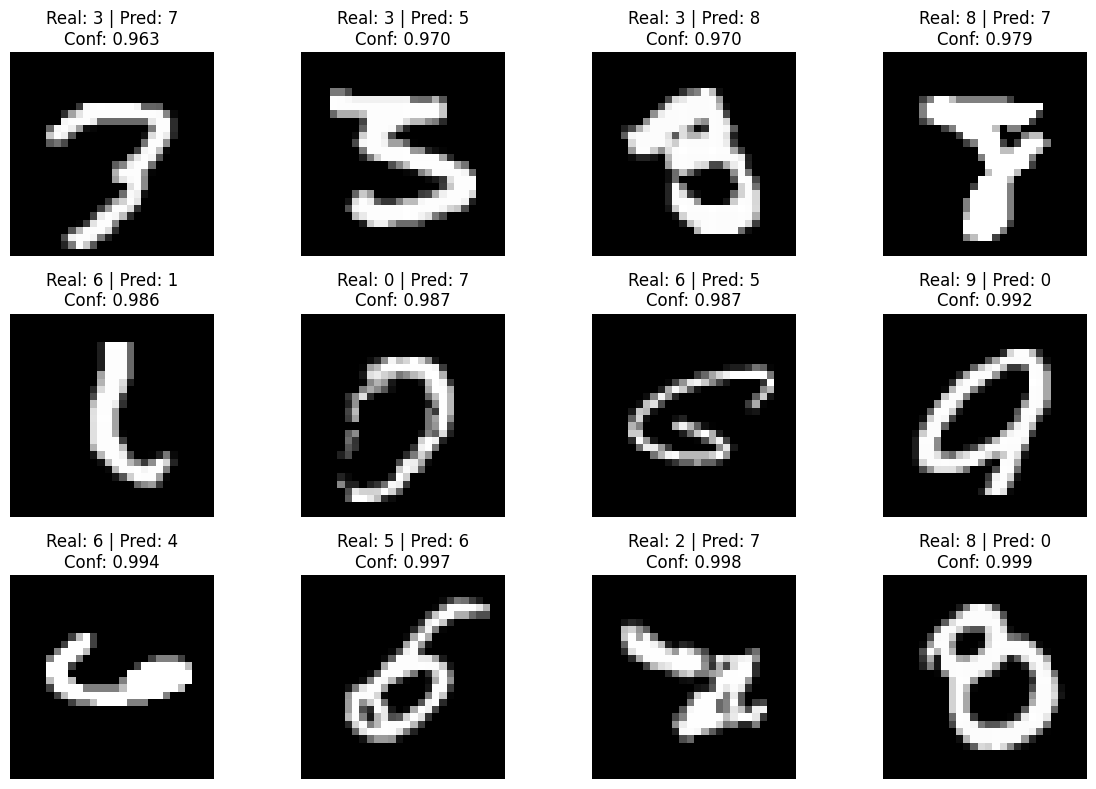

In [23]:
wrong_idx = np.where(pred_cnn != y_test)[0]
top_wrong = wrong_idx[np.argsort(confidence[wrong_idx])[-12:]]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(top_wrong):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"Real: {y_test[idx]} | Pred: {pred_cnn[idx]}\nConf: {confidence[idx]:.3f}")
    plt.axis("off")
plt.tight_layout()
plt.show()


# 20. ¿Por qué CNN gana?

Esta es una de las partes más importantes de la clase.

## Logistic Regression y Random Forest

Cuando usamos estos modelos:

- convertimos la imagen en un vector plano
- perdemos relaciones espaciales
- un pixel lejano puede ser tratado como una variable tan natural como uno cercano

## MLP

La MLP mejora porque aprende no linealidades.

Pero sigue viendo un vector, no una imagen.

## CNN

La CNN sí respeta la naturaleza del dato porque:

- trabaja con vecindades locales
- comparte parámetros
- construye representaciones jerárquicas
- detecta patrones visuales reutilizables

La superioridad de CNN aquí no es magia. Es consecuencia de la arquitectura.


# 21. Visualización de filtros

La primera capa convolucional aprende detectores simples.

En MNIST, estos filtros suelen parecerse a:

- bordes verticales
- bordes horizontales
- trazos diagonales
- zonas activadas

No debemos interpretar cada filtro como una regla humana exacta, pero sí como componentes básicos de la representación visual.


In [24]:
first_conv = cnn.layers[0]
filters, biases = first_conv.get_weights()

print("Shape de filtros:", filters.shape)


Shape de filtros: (3, 3, 1, 32)


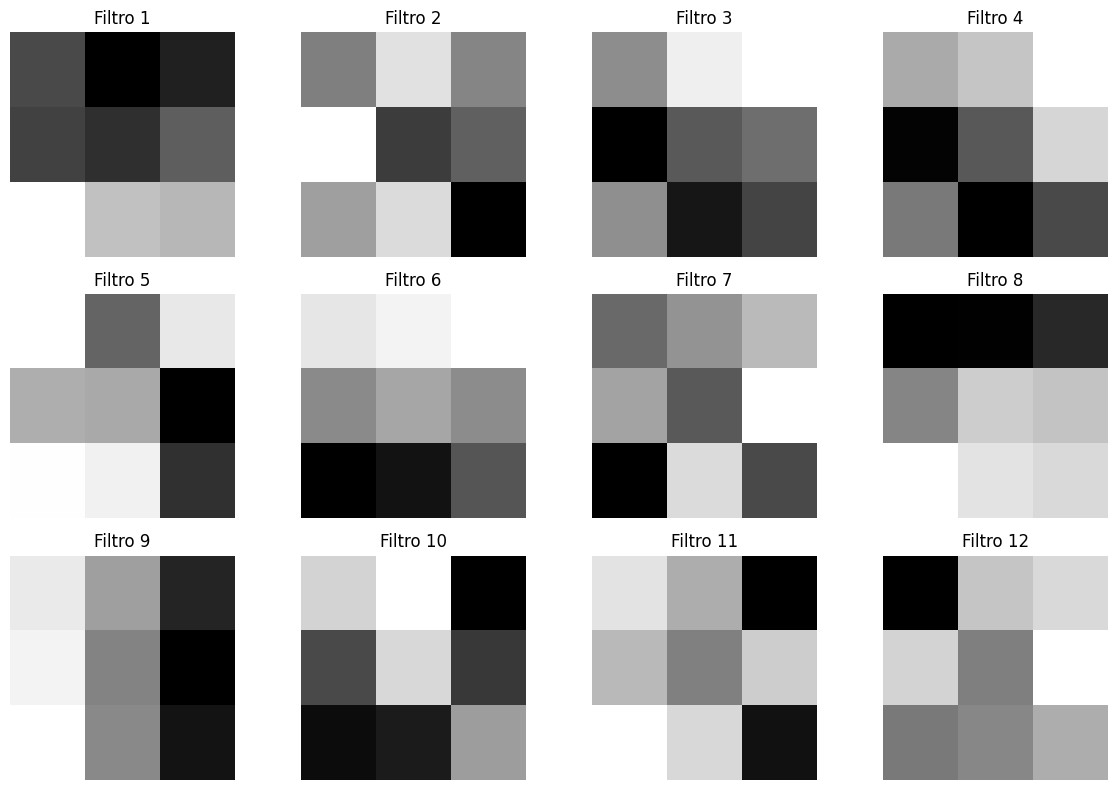

In [25]:
plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    f = filters[:, :, 0, i]
    plt.imshow(f, cmap="gray")
    plt.title(f"Filtro {i+1}")
    plt.axis("off")
plt.tight_layout()
plt.show()


# 22. Mapas de activación

Ahora veremos cómo reacciona la primera capa convolucional ante una imagen concreta.

Esto ayuda a entender que la red no “ve” la imagen como un humano. La transforma en múltiples mapas de respuesta, cada uno asociado a diferentes patrones.


In [26]:
from tensorflow.keras.models import Model

#  1. Forzar construcción del modelo
_ = cnn.predict(X_test_cnn[:1])

#  2. Crear modelo de activaciones (usar inputs, no input)
activation_model = Model(
    inputs=cnn.inputs,
    outputs=[layer.output for layer in cnn.layers if "conv2d" in layer.name]
)

#  3. Seleccionar imagen
sample_idx = 0
sample_image = X_test_cnn[sample_idx:sample_idx+1]

#  4. Obtener activaciones
activations = activation_model.predict(sample_image, verbose=0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


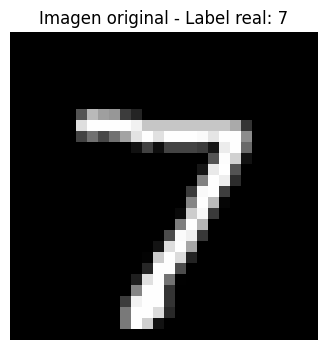

In [27]:
plt.figure(figsize=(4, 4))
plt.imshow(X_test[sample_idx], cmap="gray")
plt.title(f"Imagen original - Label real: {y_test[sample_idx]}")
plt.axis("off")
plt.show()


In [28]:
print(type(activations))
print(len(activations))

<class 'list'>
2


In [29]:
first_activation = activations[0]
print("Shape activación primera conv:", first_activation.shape)


Shape activación primera conv: (1, 26, 26, 32)


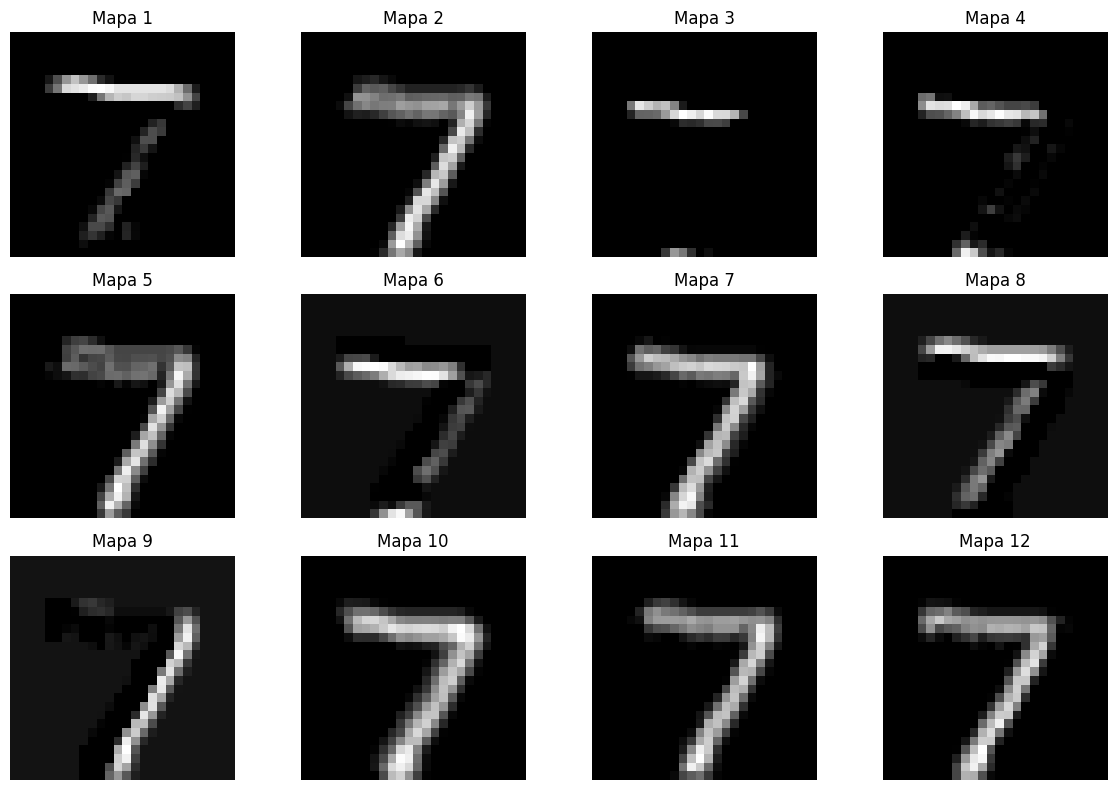

In [30]:
plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(first_activation[0, :, :, i], cmap="gray")
    plt.title(f"Mapa {i+1}")
    plt.axis("off")
plt.tight_layout()
plt.show()


# 23. Saliency map

El saliency map muestra qué regiones de la imagen influyen más en la predicción para una clase determinada.

No es interpretabilidad perfecta, pero es muy útil didácticamente porque enseña que la red concentra atención en zonas discriminantes del dígito.


In [31]:
sample_idx = 8
input_image = tf.convert_to_tensor(X_test_cnn[sample_idx:sample_idx+1])

with tf.GradientTape() as tape:
    tape.watch(input_image)
    preds = cnn(input_image)
    class_idx = tf.argmax(preds[0])
    class_score = preds[:, class_idx]

grads = tape.gradient(class_score, input_image)
saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0].numpy()


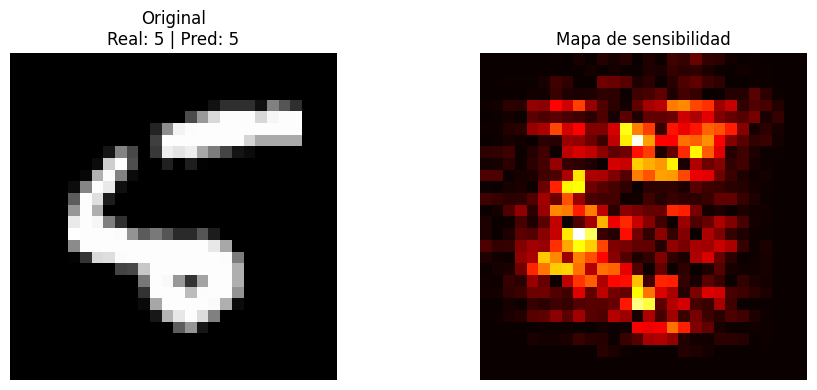

In [32]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(X_test[sample_idx], cmap="gray")
plt.title(f"Original\nReal: {y_test[sample_idx]} | Pred: {int(tf.argmax(preds[0]))}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(saliency, cmap="hot")
plt.title("Mapa de sensibilidad")
plt.axis("off")

plt.tight_layout()
plt.show()


# 24. Discusión técnica: overfitting y capacidad del modelo

En Deep Learning siempre debemos vigilar el equilibrio entre:

- capacidad del modelo
- tamaño del dataset
- regularización
- generalización

En este notebook usamos:

- `Dropout`
- `validation_split`
- `EarlyStopping`

Estas técnicas ayudan a controlar el sobreajuste y son parte del mindset correcto al entrenar redes en escenarios reales.


# 25. Comparación conceptual completa

## Logistic Regression
- baseline lineal
- rápida
- interpretable
- limitada en estructura compleja

## Random Forest
- no lineal
- robusta
- buena en muchos problemas
- pierde la geometría visual

## MLP
- aprende no linealidad compleja
- buena capacidad expresiva
- sigue ignorando estructura espacial local

## CNN
- aprovecha la estructura del dato
- aprende patrones locales
- construye jerarquías
- suele dominar en visión clásica

Conclusión formal:

$$
\text{La arquitectura correcta depende de la estructura del dato}
$$


# 26. Cierre industrial

La lección principal de esta clase no es:

> "Deep Learning siempre gana"

La lección real es:

$$
\text{Deep Learning gana cuando la arquitectura está alineada con la naturaleza del problema}
$$

## Regla práctica general

### Datos tabulares
Usualmente ganan:
- LightGBM
- XGBoost
- CatBoost

### Imágenes
Usualmente ganan:
- CNN
- Vision Transformers

### Texto
Usualmente ganan:
- Transformers
- modelos preentrenados

### Audio
Usualmente ganan:
- CNN sobre espectrogramas
- arquitecturas secuenciales o transformers

## Mensaje profesional final

El valor no está en usar Deep Learning por moda.

El valor está en saber responder:

$$
\text{¿Por qué esta arquitectura tiene sentido para este tipo de dato?}
$$


# 27. Conclusión final para alumnos

Deep Learning no reemplaza al Machine Learning tradicional.

Deep Learning se vuelve dominante cuando:

1. los datos son complejos
2. existe estructura espacial o secuencial
3. hay suficiente volumen de datos
4. la representación manual deja de ser suficiente

Por eso, un buen científico de datos o ML Engineer no solo sabe entrenar redes neuronales.

Sabe justificar técnicamente por qué una arquitectura es adecuada para un problema real.


In [33]:
print("Resumen final del experimento")
print("-" * 55)
print(f"Logistic Regression: {acc_lr:.4f}")
print(f"Random Forest      : {acc_rf:.4f}")
print(f"MLP                : {acc_mlp:.4f}")
print(f"CNN                : {acc_cnn:.4f}")
print("-" * 55)
print("Mejor modelo:", results.iloc[0]["Modelo"])


Resumen final del experimento
-------------------------------------------------------
Logistic Regression: 0.9258
Random Forest      : 0.9692
MLP                : 0.9808
CNN                : 0.9898
-------------------------------------------------------
Mejor modelo: CNN


In [34]:
# Opcional: guardar el modelo
#cnn.save("mnist_cnn_ultra_pro_full.keras")
#print("Modelo guardado correctamente.")
